In [1]:
from orbitx import TLE
import numpy as np
tle = TLE.from_sat_shortname("S6", np.datetime64("2020-02-01T00:00:00"), np.datetime64("2020-02-01T12:00:00"))
print(tle)

c:\Users\xl3\Documents\environments\orbitx\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)



TLE object for the satellite Sentinel-6 with short name S6.
Satellite catalog number: 46984.
Satellite classification: Unclassified.
Launch year: 2020.
Launch number: 87.
Launch piece: A.
Number of TLEs included: 1.
Reference date for dates in 'senconds since reference date': 1970-01-01T00:00:00.
Start date for the orbit to simulate: 2020-02-01T00:00:00.
End date for the orbit to simulate: 2020-02-01T12:00:00.
Created on 2026-01-06T13:20:26 using the version 1.0 of orbitx.



In [2]:
from orbitx import Orbit
import numpy as np


Orbit object for satellites ['Sentinel-6', 'Saral-AltiKa'].
Start date: 2020-02-01T00:00:00
End date: 2020-02-01T12:00:00
Propagation sampling interval: 20 seconds
Interpolation sampling interval: 5 seconds
Reference date used to represent time in seconds since: 2000-01-01T00:00:00
Number of simulated times: 8641.
Created on 2026-01-06T13:20:34 using the version 1.0 of orbitx.


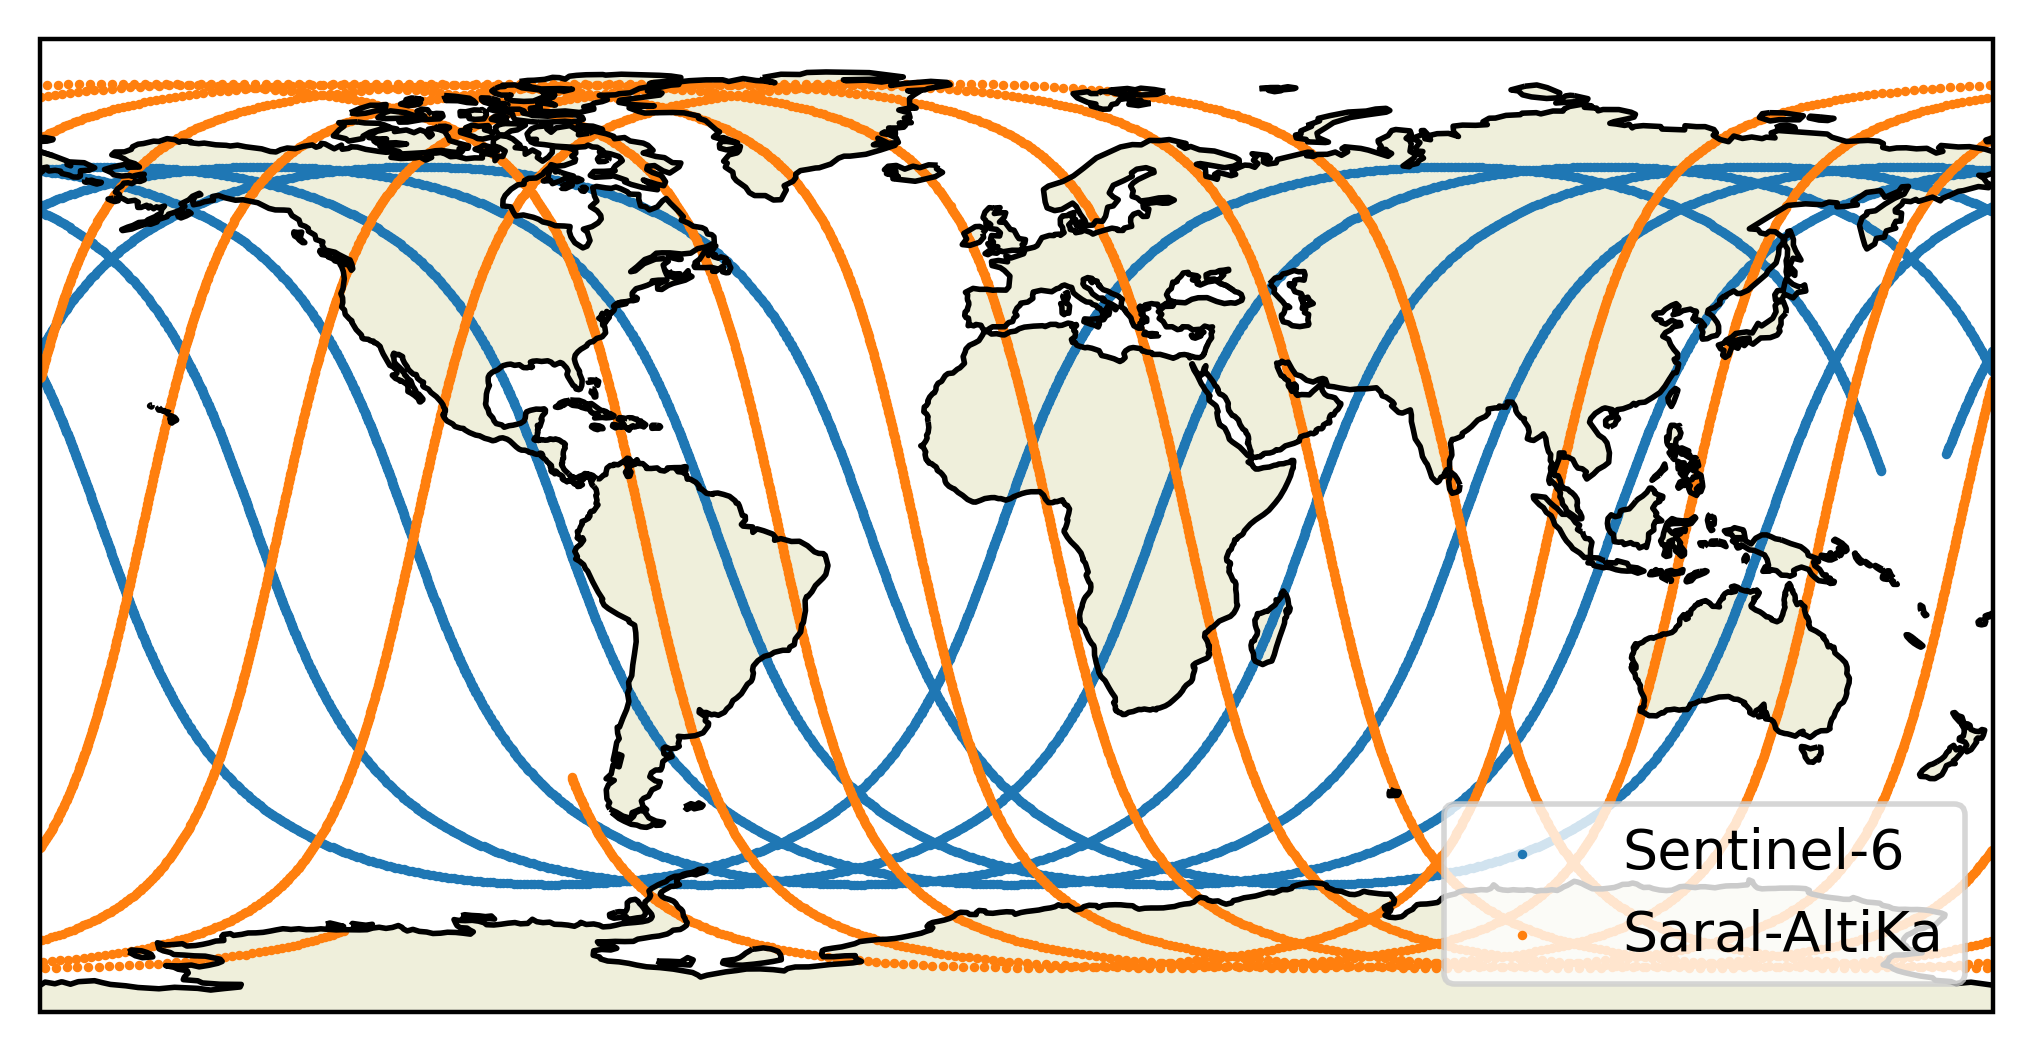

In [3]:
orbit = Orbit.simulate(
    satellites=["S6", "SA"],
    start_date=np.datetime64("2020-02-01T00:00:00"),
    end_date=np.datetime64("2020-02-01T12:00:00"),
    propagation_sampling_interval=np.array(20, dtype="timedelta64[s]"),
    interpolation_sampling_interval=np.array(5, dtype="timedelta64[s]"),
    reference_date=np.datetime64("2000-01-01T00:00:00")
)
print(orbit)
plots = orbit.plot()

In [4]:
print(orbit.orbits)

<xarray.Dataset> Size: 415kB
Dimensions:         (time: 8641, satellite: 2)
Coordinates:
  * time            (time) float64 69kB 6.338e+08 6.338e+08 ... 6.339e+08
  * satellite       (satellite) <U2 16B 'S6' 'SA'
Data variables:
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (time) datetime64[s] 69kB 2020-02-01 ... 2020-02-01T12:00:00
    lat             (time, satellite) float64 138kB 13.25 -74.64 ... -46.37
    lon             (time, satellite) float64 138kB 171.5 -124.0 ... -81.99
Attributes:
    satellite_shortname:              ['S6', 'SA']
    satellite_name:                   ['Sentinel-6', 'Saral-AltiKa']
    start_date:                       633830400.0
    end_date:                         633873600.0
    propagation_sampling_interval:    20
    interpolation_sampling_interval:  5
    version:                          1.0
    creation_date:                    2026-01-06T13:20:34


In [5]:
orbit.to_netcdf("./test_export/")

loaded_orbit = Orbit.from_netcdf("./test_export/2020-02-01_2020-02-01_psi20.0_isi5.0_orbit_S6_SA.nc")
print(loaded_orbit == orbit)


True


In [6]:
from orbitx import Matchups
import numpy as np
matchups = Matchups.find_matchups(
    satellites=["CS2", "J3"],
    start_date=np.datetime64("2012-01-01T00:00:00"),
    end_date=np.datetime64("2012-01-01T12:00:00"),
    propagation_sampling_interval = np.array(60, dtype="timedelta64[s]"),
    interpolation_sampling_interval = np.array(5, dtype="timedelta64[s]"),
    space_diff_threshold = 290,
    time_diff_threshold = np.array(900, dtype="timedelta64[s]"),
    check_before = True,
    check_after = True,
    has_land_ocean_mask = True,
    reference_date=np.datetime64("2000-01-01T00:00:00")
)

In [7]:
print(matchups)


Matchup object with following attributes:
Satellites considered: ['CryoSat-2', 'JASON-3']
Date from which matchups are looked for: 2011-12-31T23:45:00
Date until which matchups are looked for: 2012-01-01T12:15:00
Maximum time difference between members of a matchup: 900 seconds (seconds)
Maximum distance between members of a matchup: 290.0 (km)
Are matchups in which on of the satellites appears before the start date considered? True
Are matchups in which on of the satellites appears after the end date considered? True
Has this matchup a land/ocean mask? True
Number of matchups found: 53.
Created on 2026-01-06T13:20:37 using the version 1.0 of orbitx.



In [8]:
print(matchups.matchups)

<xarray.DatasetView> Size: 5kB
Dimensions:         (matchup_index: 53, satellite: 2, satellite_pair: 1)
Coordinates:
  * satellite       (satellite) <U3 24B 'CS2' 'J3'
  * satellite_pair  (satellite_pair) <U6 24B 'CS2_J3'
  * matchup_index   (matchup_index) int64 424B 0 1 2 3 4 5 ... 47 48 49 50 51 52
Data variables:
    reference_date  datetime64[s] 8B 2000-01-01
    time_datetime   (matchup_index, satellite) datetime64[s] 848B 2012-01-01T...
    time            (matchup_index, satellite) float64 848B 3.787e+08 ... 3.7...
    lat             (matchup_index, satellite) float64 848B 63.72 66.12 ... 66.1
    lon             (matchup_index, satellite) float64 848B -173.1 ... 159.0
    distance        (matchup_index, satellite_pair) float64 424B 279.4 ... 287.3
    delay           (matchup_index, satellite_pair) timedelta64[s] 424B 00:09...
    land_mask       (matchup_index, satellite) <U1 424B 'O' 'O' 'O' ... 'O' 'O'
    matchup_type    (matchup_index) <U1 212B 'O' 'O' 'O' 'O' ... 'O' 'O

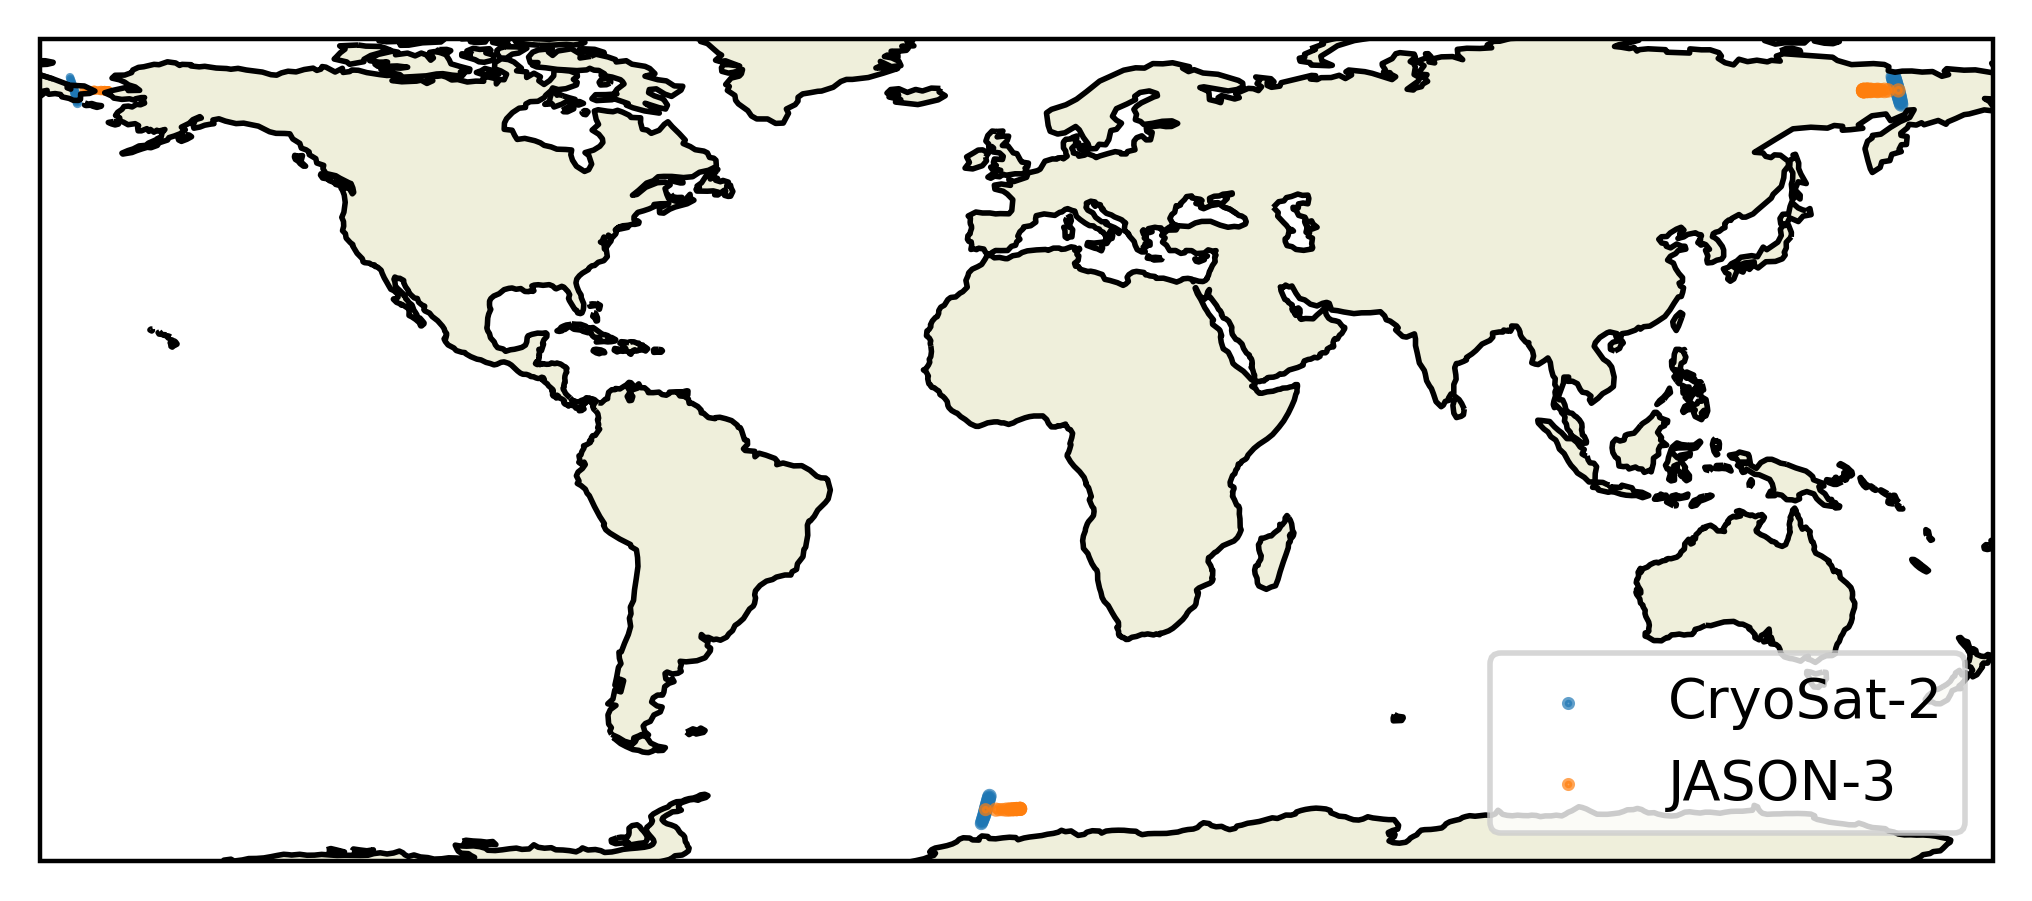

In [10]:
fig = matchups.plot()
fig.savefig("./test_export/matchup_plot.png")

In [11]:
matchups.to_netcdf("./test_export/")

In [12]:
from orbitx import Matchups
loaded_matchup = Matchups.from_netcdf("./test_export/2011-12-31_2012-01-01_psi60.0_isi5.0_matchups_CS2_J3_c2c290_tdt900.nc")

In [13]:
print(matchups == loaded_matchup)

True
